# Battleship — Monte Carlo Strategy Simulation

**Objective:** find which firing strategy sinks a full Battleship fleet in the fewest shots, how large and how reliable the gap between strategies is, and — from the defender's side — whether *how* you place your ships changes how long you survive.
**Method:** a Battleship rules engine and four attacker strategies (Random → Hunt & Target → Hunt & Target + Parity → Probability Density) built in Python, each played on thousands of identical, randomly placed boards (Monte Carlo). No external data: every number below comes from the simulation, so the board size, fleet, and game count are just parameters.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, ".")
import BS_game as game
import BS_strategies as strat
import BS_simulation as sim
import BS_visualizations as viz

RESULT_DIR = "../result"
FIG_DIR = os.path.join(RESULT_DIR, "figures")
DATA_DIR = "../data"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

## Parameters

Every input that shapes the analysis lives here, in one place — change the board, the fleet, or the number of simulated games by editing this cell and re-running.

In [2]:
# Classic Milton Bradley rules: 10x10 board, five ships, 17 ship cells in total.
BOARD_SIZE = 10
FLEET = {"Carrier": 5, "Battleship": 4, "Cruiser": 3, "Submarine": 3, "Destroyer": 2}

# Games simulated per strategy (STEP 03-06) and per attacker x placement style (STEP 08-09).
N_GAMES = 3000
N_DEFENSE_GAMES = 1500

# Boards sampled to estimate where each placement style tends to put ships (STEP 02, 09).
N_OCCUPANCY_BOARDS = 5000

SEED = 42

## STEP 01 - Game Engine: Placing a Fleet

`BS_game.place_fleet` places each ship uniformly at random among the positions still legal (horizontal or vertical, no overlap). One example board:

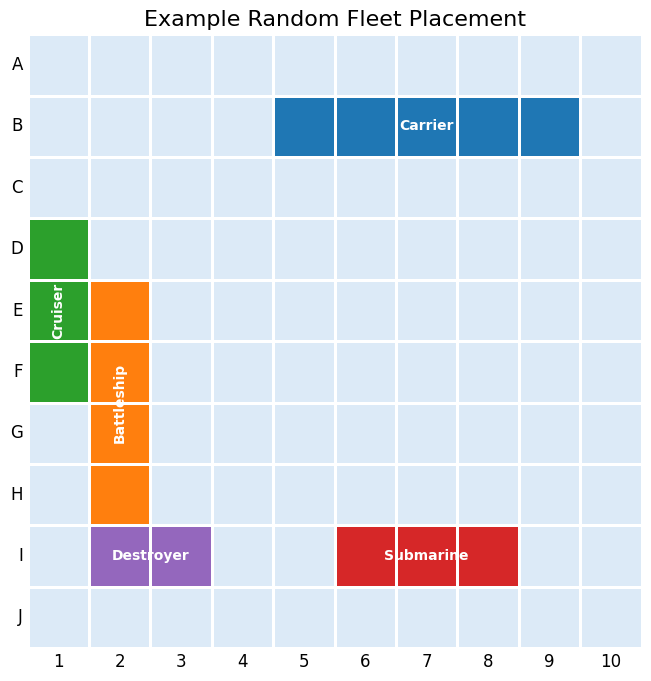

Board: 10x10 = 100 cells | 5 ships | 17 ship cells (17% of the board)


In [3]:
example_board = game.place_fleet(BOARD_SIZE, FLEET, np.random.default_rng(SEED))
viz.plot_board(example_board, "Example Random Fleet Placement", os.path.join(FIG_DIR, "example_board.png"))
plt.show()

print(f"Board: {BOARD_SIZE}x{BOARD_SIZE} = {BOARD_SIZE**2} cells | {len(FLEET)} ships | {sum(FLEET.values())} ship cells "
      f"({sum(FLEET.values()) / BOARD_SIZE**2:.0%} of the board)")

## STEP 02 - Where Are Ships Most Likely to Be?

Before a single shot, not every cell is equally likely to hold a ship. Two independent views of the same question:
- **Analytic:** for each cell, how many legal ship positions cover it (the Probability Density strategy's opening map).
- **Empirical:** share of simulated random boards on which that cell actually holds a ship.

If the two agree, the probability model is describing the real placement process.

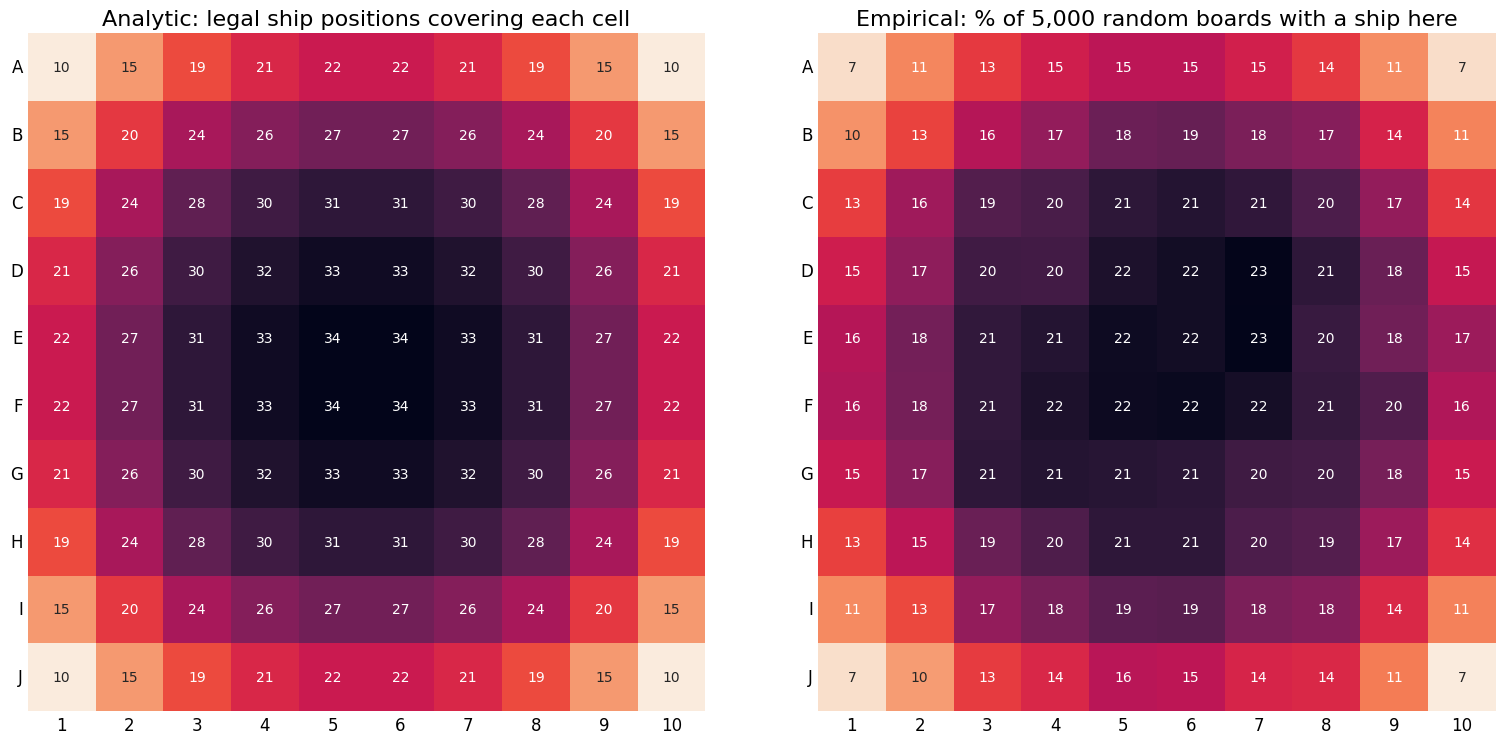

Correlation analytic vs empirical: 0.990
Corner cells hold a ship on 7.3% of boards; the 4 centre cells on 22.3%


In [4]:
empty_view = np.full(BOARD_SIZE**2, game.UNKNOWN)
opening_density = strat.probability_map(empty_view, list(FLEET.values()), BOARD_SIZE)
random_occupancy = sim.empirical_occupancy(BOARD_SIZE, FLEET, "random", N_OCCUPANCY_BOARDS, SEED)

viz.plot_heatmaps({
    "Analytic: legal ship positions covering each cell": opening_density,
    f"Empirical: % of {N_OCCUPANCY_BOARDS:,} random boards with a ship here": random_occupancy * 100,
}, BOARD_SIZE, os.path.join(FIG_DIR, "opening_probability.png"))
plt.show()

corr = np.corrcoef(opening_density, random_occupancy)[0, 1]
grid = random_occupancy.reshape(BOARD_SIZE, BOARD_SIZE)
print(f"Correlation analytic vs empirical: {corr:.3f}")
print(f"Corner cells hold a ship on {grid[[0, 0, -1, -1], [0, -1, 0, -1]].mean():.1%} of boards; "
      f"the 4 centre cells on {grid[4:6, 4:6].mean():.1%}")

## STEP 03 - Simulate Every Strategy

Each strategy plays `N_GAMES` games. Game *g* uses the same board for every strategy (seeded by `(SEED, g)`), so the comparison is paired: differences come from the strategy, not board luck.

| Level | Strategy | Idea |
|---|---|---|
| 1 | Random | Fire at any unfired cell (baseline) |
| 2 | Hunt & Target | Random until a hit, then fire at the cells around it |
| 3 | Hunt & Target + Parity | Same, but hunt only on a checkerboard — every ship must cover one of those cells |
| 4 | Probability Density | Fire where the most still-possible ship positions overlap |

### How each strategy picks its next shot

The same board at the same moment, seen by each strategy. Shaded cells are the ones it considers for its next shot.
- **Top row, hunting (no hit yet):** Random and Hunt & Target consider every unfired cell. Parity skips half the board, because no ship can hide between checkerboard cells. Probability Density ranks every cell and aims at the centre, where the most ship positions fit.
- **Bottom row, targeting (two hits side by side on E5, E6):** Random ignores the hits. Both Hunt & Target variants treat all 6 neighbouring cells as equally good. Probability Density works out that the ship most likely continues **along the same line** (E4 or E7), so it fires there first and wastes fewer shots.

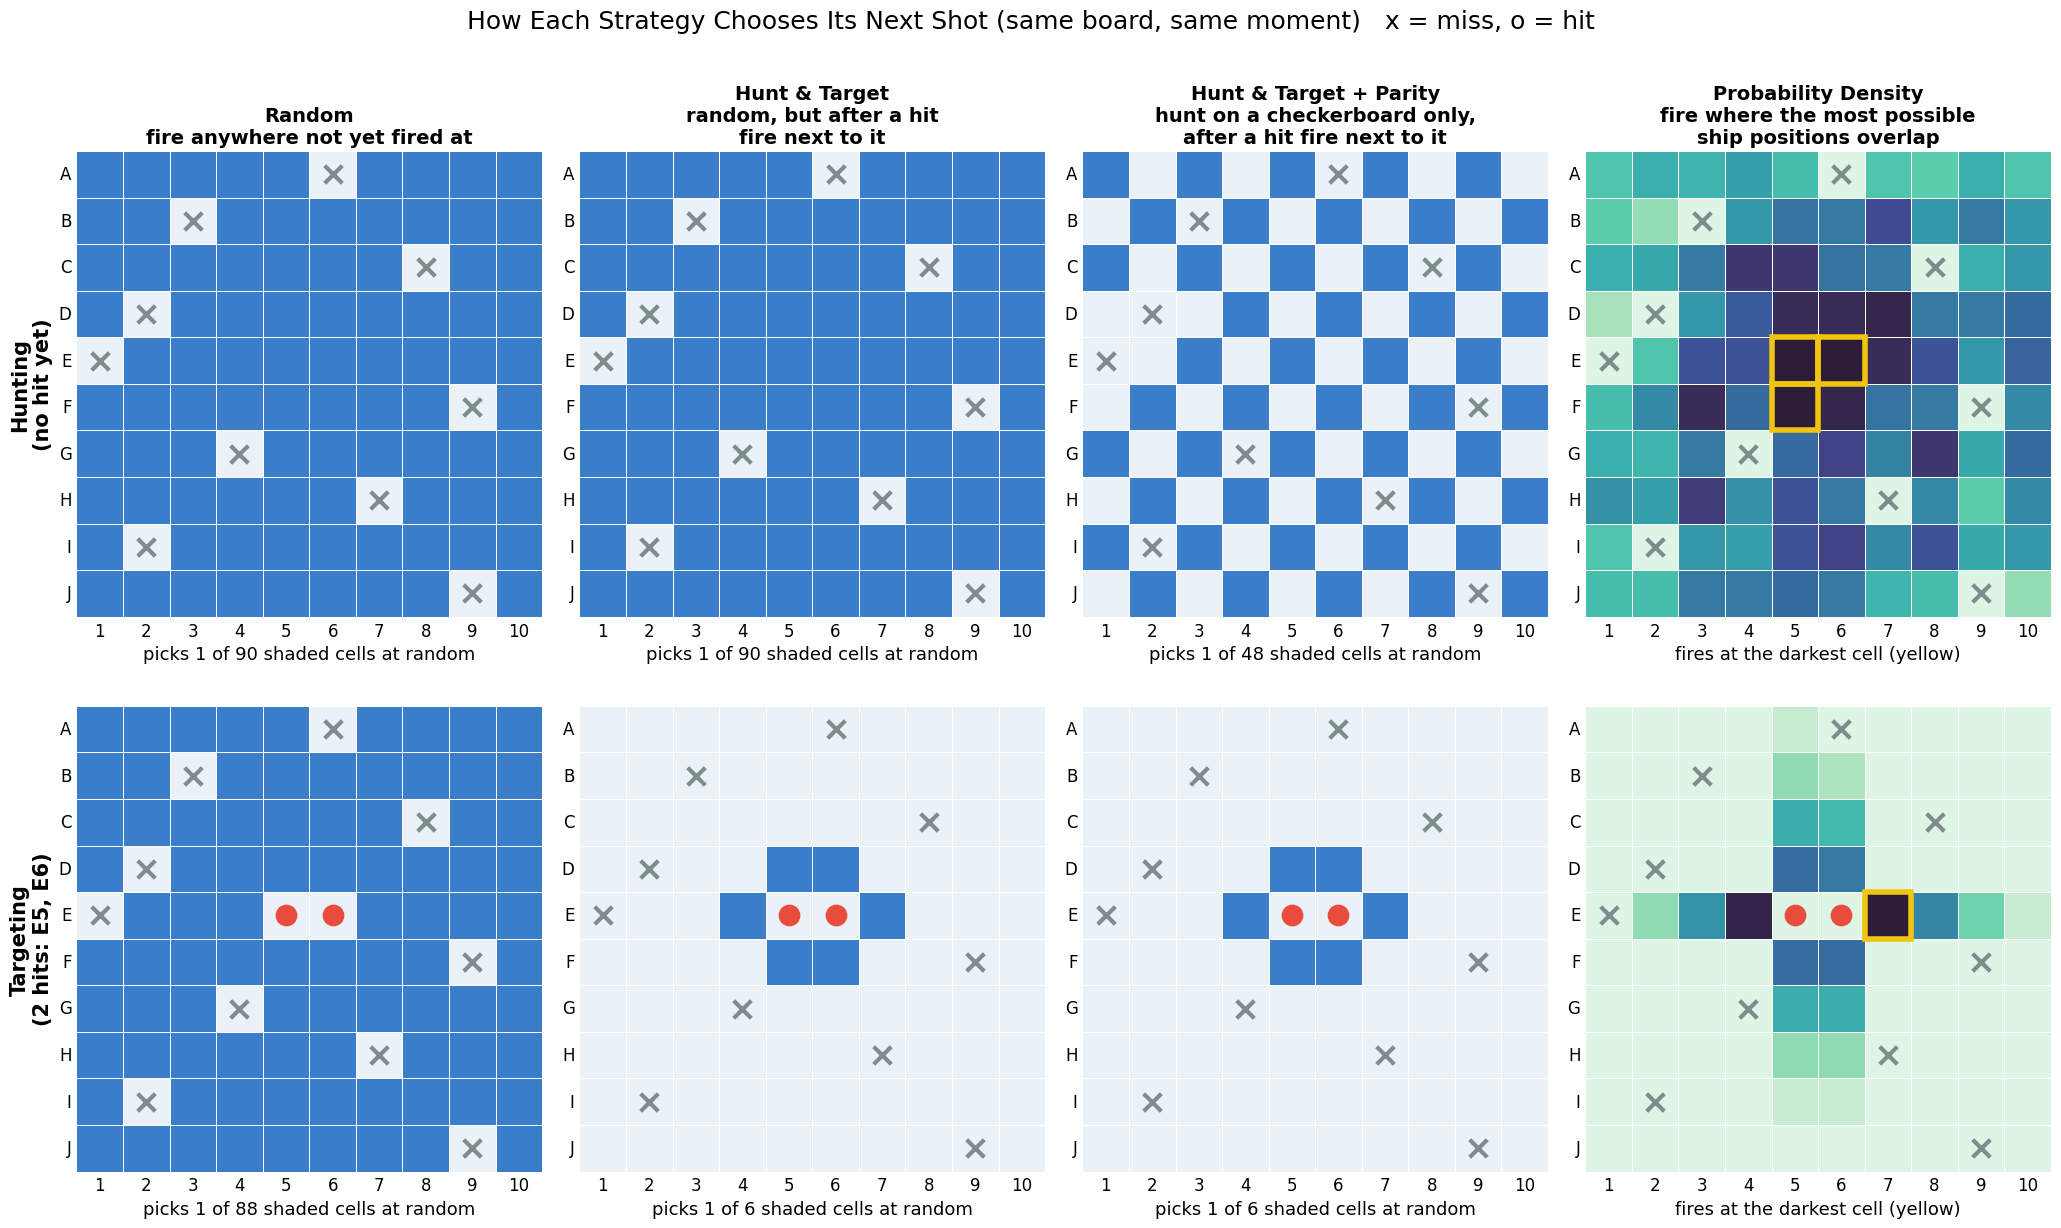

In [5]:
def board_cell(name):
    """'E5' -> flat index on the board (rows A-J, columns 1-10)."""
    return (ord(name[0]) - ord("A")) * BOARD_SIZE + int(name[1:]) - 1

hunting = np.full(BOARD_SIZE**2, game.UNKNOWN)
for name in ["B3", "C8", "D2", "F9", "G4", "H7", "I2", "J9", "A6", "E1"]:
    hunting[board_cell(name)] = game.MISS
targeting = hunting.copy()
targeting[[board_cell("E5"), board_cell("E6")]] = game.HIT

viz.plot_strategy_decisions(
    {"Hunting\n(no hit yet)": hunting, "Targeting\n(2 hits: E5, E6)": targeting},
    list(FLEET.values()), BOARD_SIZE, os.path.join(FIG_DIR, "strategy_decisions.png"))
plt.show()

In [6]:
results = sim.run_simulation(strat.STRATEGIES, N_GAMES, BOARD_SIZE, FLEET, SEED)
results.to_csv(os.path.join(DATA_DIR, "strategy_results.csv"), index=False)
print(f"{len(results):,} games simulated")
results.head()

12,000 games simulated


,strategy,placement,game,shots
0,Random,random,0,94
1,Random,random,1,88
2,Random,random,2,96
3,Random,random,3,98
4,Random,random,4,98


## STEP 04 - How Many Shots Does Each Strategy Need?

,mean,median,std,p10,p90,min,max,win_within_50
strategy,,,,,,,,
Random,95.18,97.0,5.02,88.0,100.0,67,100,0.00
Hunt & Target,62.53,62.0,13.84,45.0,81.0,26,99,0.21
Hunt & Target + Parity,54.64,55.0,8.75,43.0,65.0,27,81,0.31
Probability Density,44.78,44.0,9.04,34.0,57.0,22,72,0.75


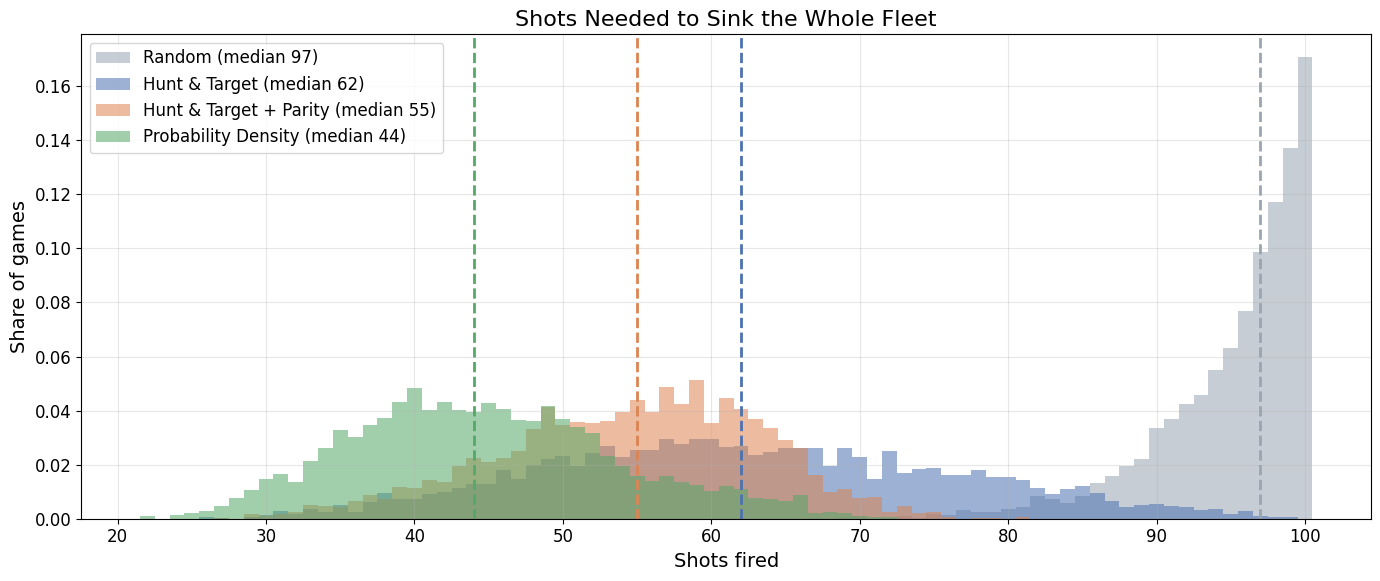

In [7]:
summary = sim.summarize(results)
summary.to_csv(os.path.join(DATA_DIR, "strategy_summary.csv"))
display(summary)

viz.plot_shots_distribution(results, os.path.join(FIG_DIR, "shots_distribution.png"))
plt.show()

## STEP 05 - Probability of Winning Within N Shots

The cumulative view answers the practical question — "by shot N, how likely am I to have already won?" — and shows where each curve crosses 50% (the median).

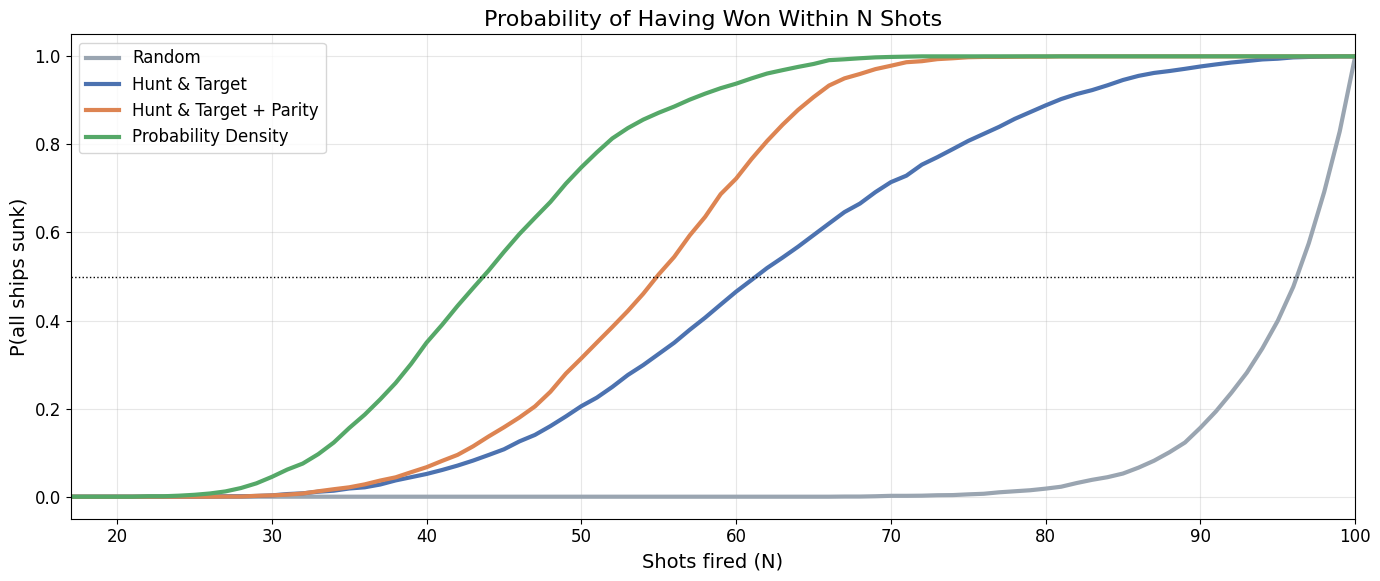

Random                   wins within 40 shots:   0.0% | within 60:   0.0%
Hunt & Target            wins within 40 shots:   5.2% | within 60:  46.6%
Hunt & Target + Parity   wins within 40 shots:   6.7% | within 60:  72.2%
Probability Density      wins within 40 shots:  35.0% | within 60:  93.8%


In [8]:
viz.plot_shots_cdf(results, os.path.join(FIG_DIR, "shots_cdf.png"))
plt.show()

for name, shots in results.groupby("strategy", sort=False)["shots"]:
    print(f"{name:<24} wins within 40 shots: {(shots <= 40).mean():6.1%} | within 60: {(shots <= 60).mean():6.1%}")

## STEP 06 - Are the Improvements Significant?

Wilcoxon signed-rank test, each strategy against the next level up — paired by game, since both played the same board.

In [9]:
significance = sim.compare_consecutive(results)
display(significance.style.format({"p_value": "{:.2e}", "share_games_better": "{:.1%}"}))

,comparison,mean_shots_saved,share_games_better,p_value
0,Hunt & Target vs Random,32.650000,99.2%,0.00e+00
1,Hunt & Target + Parity vs Hunt & Target,7.890000,67.8%,1.36e-144
2,Probability Density vs Hunt & Target + Parity,9.860000,77.1%,8.43e-261


## STEP 07 - Inside One Game: What the Probability Density Attacker Sees

Replaying one game shot by shot: the heatmap is the attacker's probability map *before* each shot, the yellow box is the cell it chooses. Watch it switch from **hunt mode** (spread-out map) to **target mode** (map collapses around a hit) and back.

Game won in 50 shots


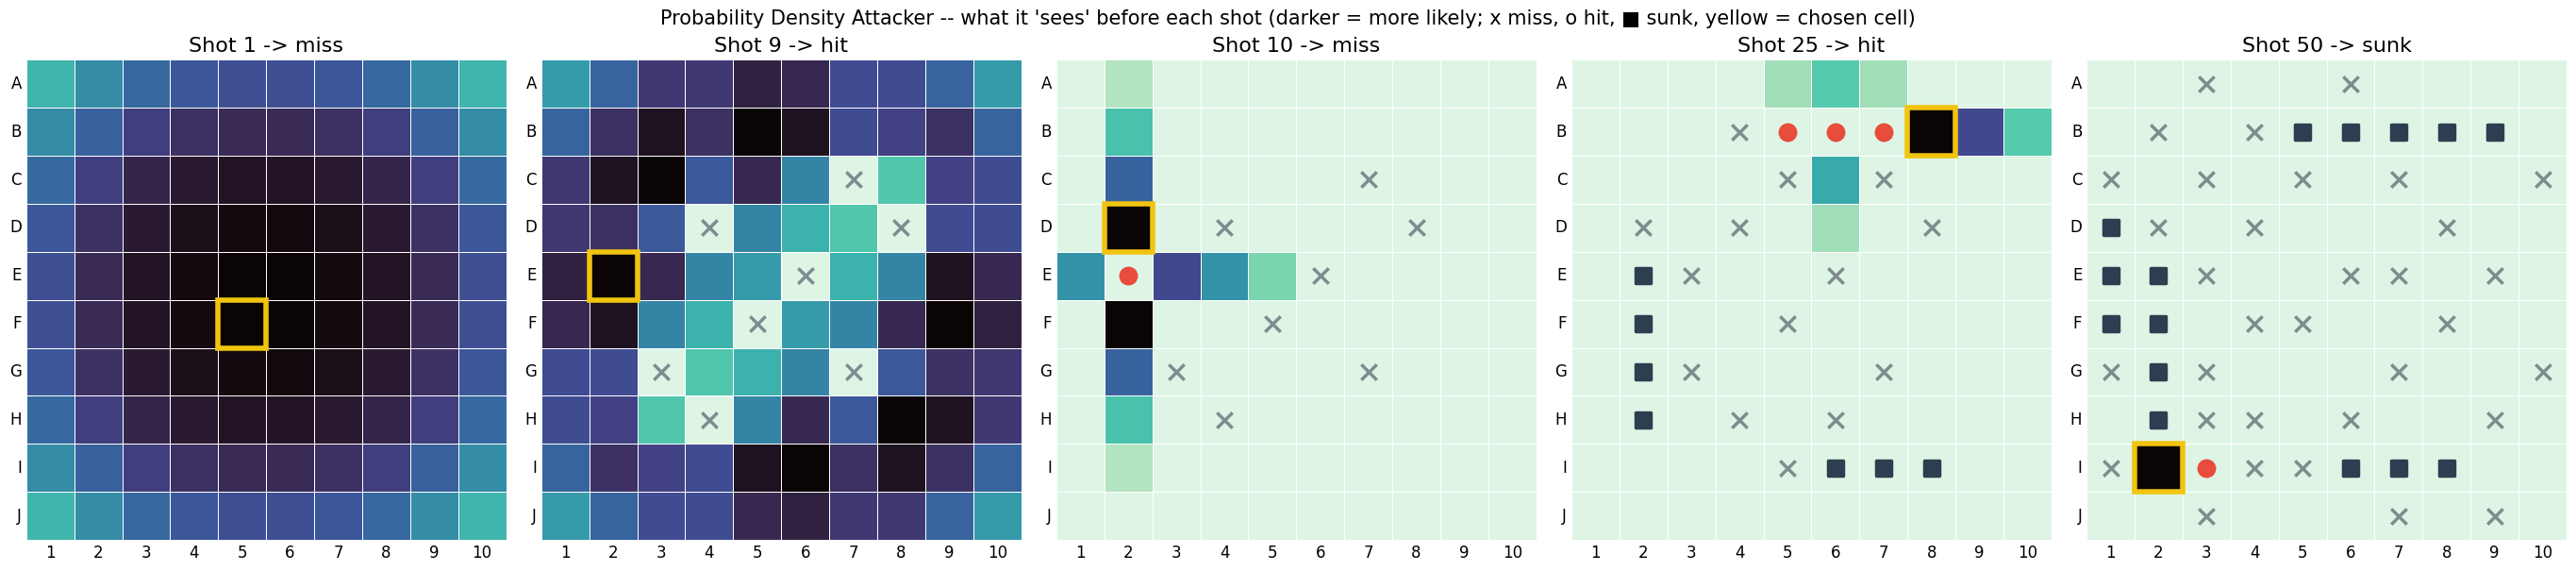

Full game animation saved to result/figures/probability_density_game.gif


In [10]:
replay_board = game.place_fleet(BOARD_SIZE, FLEET, np.random.default_rng([SEED, 0]))
n_shots, game_log = sim.play_game(replay_board, strat.probability_density, np.random.default_rng([SEED, 0, 1]), record=True)
print(f"Game won in {n_shots} shots")

first_hit = next(e["shot"] for e in game_log if e["result"] != "miss")
snapshot_shots = sorted({1, first_hit, first_hit + 1, n_shots // 2, n_shots})
viz.plot_game_snapshots(game_log, BOARD_SIZE, snapshot_shots, os.path.join(FIG_DIR, "game_snapshots.png"))
plt.show()

viz.save_game_gif(game_log, BOARD_SIZE, os.path.join(FIG_DIR, "probability_density_game.gif"))
print("Full game animation saved to result/figures/probability_density_game.gif")

## STEP 08 - Defense: Does Placement Style Matter?

Switching sides. Four ways a defender might place ships:
- **random** — any legal position (what STEP 03 used)
- **edge** — hug the border ("nobody shoots the corners")
- **cluster** — ships touching each other
- **spread** — no two ships touch, not even diagonally

First against the attackers from STEP 03, which assume a randomly placing opponent.

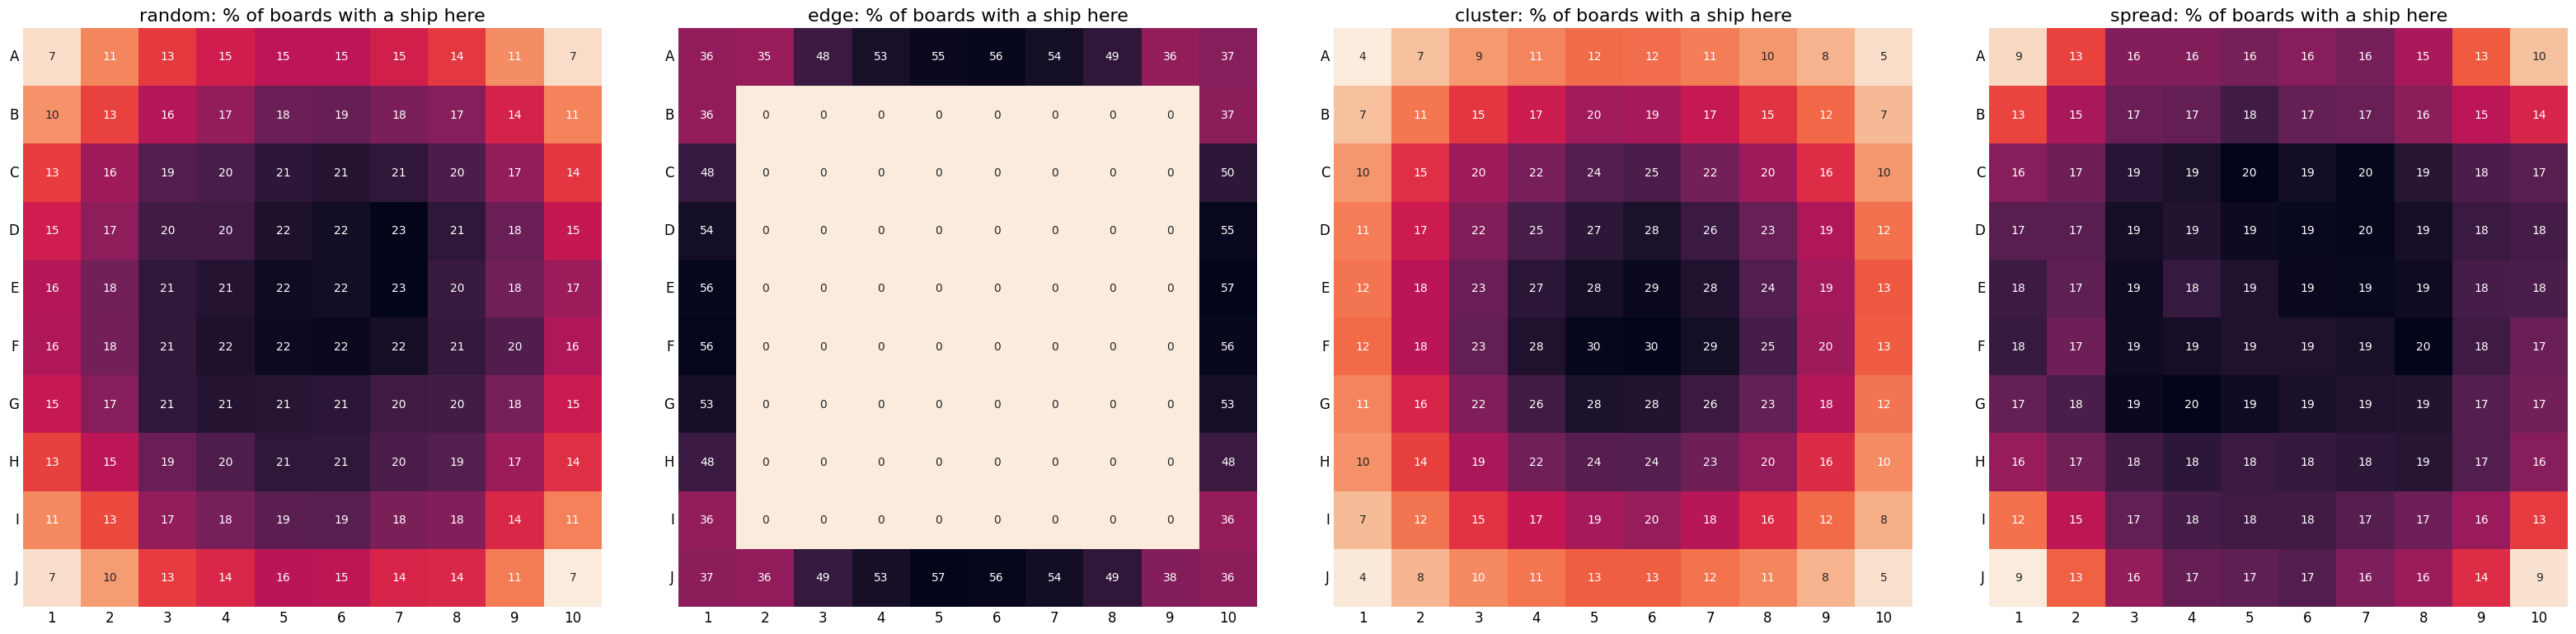

In [11]:
viz.plot_heatmaps({
    f"{style}: % of boards with a ship here": sim.empirical_occupancy(BOARD_SIZE, FLEET, style, N_OCCUPANCY_BOARDS, SEED) * 100
    for style in game.PLACEMENT_STYLES
}, BOARD_SIZE, os.path.join(FIG_DIR, "placement_styles.png"))
plt.show()

## STEP 09 - The Adaptive Attacker

A real opponent can *learn* your habits. The **adaptive** attacker multiplies its hunt-mode probability map by a prior: how much more (or less) often this opponent's style puts a ship on each cell compared with random placement, estimated from `N_OCCUPANCY_BOARDS` observed boards. Against a random placer that prior is ~1 everywhere, so it behaves exactly like the naive attacker.

The question this answers: is any "clever" placement actually better than random once the opponent catches on?

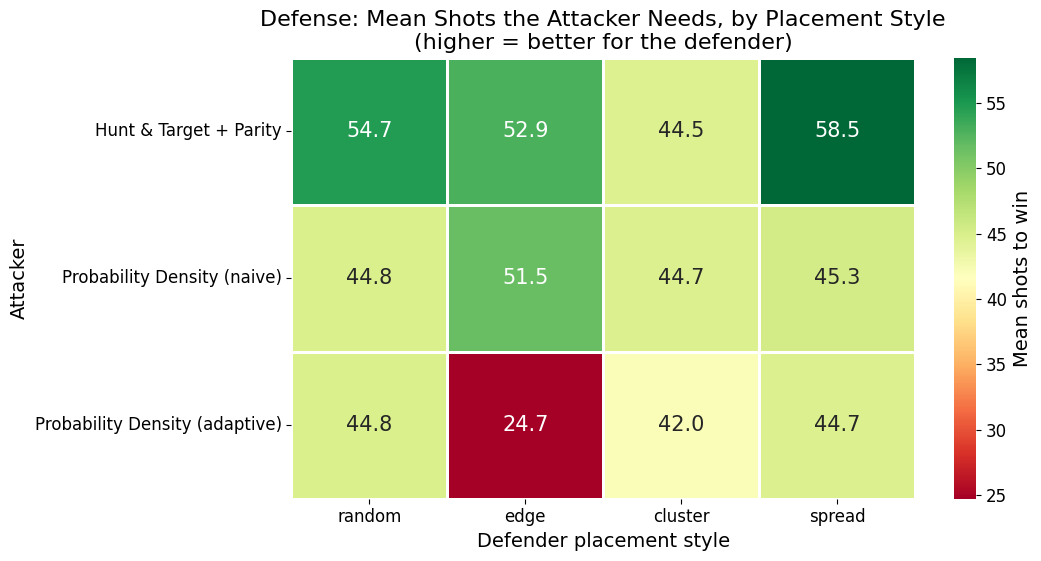

placement,random,edge,cluster,spread
strategy,,,,
Hunt & Target + Parity,54.7,52.9,44.5,58.5
Probability Density (naive),44.8,51.6,44.7,45.3
Probability Density (adaptive),44.8,24.7,42.0,44.7


In [12]:
occupancy = {style: sim.empirical_occupancy(BOARD_SIZE, FLEET, style, N_OCCUPANCY_BOARDS, SEED)
             for style in game.PLACEMENT_STYLES}
eps = 1e-3
habit_prior = {style: (occupancy[style] + eps) / (occupancy["random"] + eps) for style in game.PLACEMENT_STYLES}

attackers = {
    "Hunt & Target + Parity": lambda style: strat.hunt_target_parity,
    "Probability Density (naive)": lambda style: strat.probability_density,
    "Probability Density (adaptive)": lambda style: strat.make_probability_density(prior=habit_prior[style]),
}
defense = sim.run_defense_matrix(attackers, game.PLACEMENT_STYLES, N_DEFENSE_GAMES, BOARD_SIZE, FLEET, SEED)
defense.to_csv(os.path.join(DATA_DIR, "defense_results.csv"), index=False)

defense_pivot = defense.pivot_table(index="strategy", columns="placement", values="shots", aggfunc="mean")
defense_pivot = defense_pivot.loc[list(attackers), list(game.PLACEMENT_STYLES)]
viz.plot_defense_matrix(defense_pivot, os.path.join(FIG_DIR, "defense_matrix.png"))
plt.show()
defense_pivot.round(1)

In [13]:
naive = defense_pivot.loc["Probability Density (naive)"]
adaptive = defense_pivot.loc["Probability Density (adaptive)"]
for style in game.PLACEMENT_STYLES:
    print(f"{style:<8} vs naive: {naive[style]:5.1f} shots | vs adaptive: {adaptive[style]:5.1f} shots "
          f"| learning the habit saves the attacker {naive[style] - adaptive[style]:+5.1f} shots")

random   vs naive:  44.8 shots | vs adaptive:  44.8 shots | learning the habit saves the attacker  +0.0 shots
edge     vs naive:  51.5 shots | vs adaptive:  24.7 shots | learning the habit saves the attacker +26.8 shots
cluster  vs naive:  44.7 shots | vs adaptive:  42.0 shots | learning the habit saves the attacker  +2.7 shots
spread   vs naive:  45.3 shots | vs adaptive:  44.7 shots | learning the habit saves the attacker  +0.7 shots


A defender doesn't know which attacker they'll face, so the robust choice is the style whose **worst case** (fewest shots across all attackers) is highest — the maximin view from game theory. Standard errors are about ±0.2–0.3 shots at `N_DEFENSE_GAMES = 1500`, so gaps smaller than ~1 shot are a tie.

In [14]:
robustness = pd.DataFrame({
    "worst_case_shots": defense_pivot.min(),
    "worst_case_attacker": defense_pivot.idxmin(),
    "best_case_shots": defense_pivot.max(),
}).sort_values("worst_case_shots", ascending=False).round(1)
robustness

,worst_case_shots,worst_case_attacker,best_case_shots
placement,,,
random,44.8,Probability Density (naive),54.7
spread,44.7,Probability Density (adaptive),58.5
cluster,42.0,Probability Density (adaptive),44.7
edge,24.7,Probability Density (adaptive),52.9
